## 1. Fairness metrics Overview

### Composite Unfairness Score

$$\text{Unfairness} = \alpha \cdot DP + \beta \cdot EO + \gamma \cdot CAL$$

where $\alpha + \beta + \gamma = 1$ and all weights are non-negative. The score is an **unfairness score** — higher means less fair. Since DP, EO, and CAL are each individually bounded in $[0,1]$ (see below), and $\alpha+\beta+\gamma=1$, the composite is a convex combination of bounded quantities and is itself bounded in $[0,1]$.

---

### Demographic Parity (DP)

$$DP = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left| P(\hat{y}=1 \mid g,a) - P(\hat{y}=1 \mid 1,a) \right| \right]$$

Measures whether approval rates differ across subgroups. $g=1$ denotes the reference subgroup for attribute $a$.

The inner average over $g$ divides by $G_a - 1$ (the number of non-reference subgroups) rather than summing raw gaps. Without this, an attribute with more subgroups (e.g. race, with 5 non-reference groups) would mechanically inflate its contribution relative to an attribute with fewer subgroups (e.g. sex, with 2 non-reference groups) — not because the underlying disparities are larger, but purely because there are more terms in the sum. Dividing by $G_a-1$ converts each attribute's contribution into an *average* gap, removing this artifact of subgroup count.

The outer average over $a$ divides by $A$ for the same reason one level up, and additionally ensures $DP \in [0,1]$: each inner bracket is bounded in $[0,1]$ (an average of probability differences, each individually in $[0,1]$), so summing $A$ such brackets gives $[0,A]$, and dividing by $A$ rescales to $[0,1]$.

This construction assumes $A$ — the set of protected attributes included — is identical across DP, EO, and CAL. We hold this fixed deliberately: selectively excluding a protected attribute from one metric is a structurally detectable form of gaming (a regulator can simply ask "why is sex absent from your EO calculation?"), addressable by a basic completeness requirement. This is qualitatively different from the weighting manipulation ($\alpha$, $\beta$, $\gamma$, and $B$ — see below) that this dissertation is concerned with, where every choice of parameter still produces a number that looks like a legitimate fairness score.

---

### Equalised Odds (EO)

$$EO = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \frac{1}{2}\left( \left| P(\hat{y}=1 \mid y=1,g,a) - P(\hat{y}=1 \mid y=1,1,a) \right| + \left| P(\hat{y}=1 \mid y=0,g,a) - P(\hat{y}=1 \mid y=0,1,a) \right| \right) \right]$$

Measures whether TPR and FPR differ across subgroups. The two terms inside the parentheses capture the TPR gap and FPR gap respectively.

The same $\frac{1}{G_a-1}$ and $\frac{1}{A}$ normalisations apply here as in DP, and for the same reasons. EO additionally requires a $\frac{1}{2}$ that DP does not: each inner term sums *two* gaps (TPR and FPR), each individually bounded in $[0,1]$, so their sum is bounded in $[0,2]$ rather than $[0,1]$. The $\frac12$ averages the TPR gap and FPR gap together, bringing the inner bracket back to $[0,1]$ and keeping it on the same scale as DP's inner bracket — necessary for $DP$, $EO$, and $CAL$ to be comparable once combined via $\alpha$, $\beta$, $\gamma$. Placing the $\frac12$ at this innermost level (rather than factoring it out front) keeps every layer of the expression independently interpretable: the bracket is "the average of the TPR gap and FPR gap for subgroup $g$," not an arbitrary partial sum awaiting a distant normalising constant.

---

### Calibration (CAL)

$$ CAL = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a}\sum_{g=1}^{G_a} \left(\frac{1}{B}\sum_{b=1}^B \left| \bar{p}_{b,g,a} - P(y=1 \mid b,g,a) \right| \right) \right] $$

Measures whether predicted probabilities reflect actual outcomes within each subgroup.

$\bar{p}_{b,g,a}$ denotes the average predicted probability assigned by the classifier to observations in calibration bin b, subgroup g, and protected attribute a.

The innermost average over $b$ divides by $B$, the number of calibration bins, applying the same bounding logic as the other layers: each bin-level calibration error is an absolute difference between the average predicted probability and the observed proportion of positive outcomes, and is therefore bounded in $[0,1]$. Averaging over $B$ bins keeps the result in $[0,1]$. The same $\frac{1}{A}$ normalisation then applies as in DP and EO. Unlike DP and EO, however, CAL does not compare each subgroup against a reference subgroup, so the averaging is performed over all subgroups using $\frac{1}{G_a}$ rather than $\frac{1}{G_a-1}$. Unlike EO, no additional rescaling constant is needed beyond the averaging layers, since CAL consists of repeated instances of the same quantity—a calibration error evaluated per bin—rather than two structurally different quantities (TPR gap and FPR gap) that must be reconciled into a single comparable unit.

$B$ is itself a free, tuneable parameter, set by whoever implements the monitoring system, with no value specified or implied by regulation. Unlike $\alpha,\beta,\gamma$, which form a continuous 2-dimensional simplex, $B$ is a positive integer with no natural upper bound, so sensitivity to $B$ is not the same kind of exercise as sensitivity to $(\alpha,\beta,\gamma)$ and should be examined separately. Too few bins make CAL uninformative (coarse probability ranges hide miscalibration); too many make bins sparse, especially for smaller subgroups, producing noisy and unstable estimates. Because CAL is itself sensitive to $B$, $\gamma$'s effective influence on the composite score is partly a function of the chosen value of $B$—meaning a robustness check that sweeps $(\alpha,\beta,\gamma)$ and a robustness check that sweeps $B$ are not fully independent and may need to be considered jointly.

---

### Reference Groups

| Attribute | Reference group |
|---|---|
| Race | White |
| Ethnicity | Not Hispanic or Latino |
| Sex | Male |

---

### Notes

- $a$ denotes a protected attribute; $A$ is the total number of protected attributes
- $g$ indexes subgroups within attribute $a$; $G_a$ is the number of subgroups for attribute $a$
- $g=1$ is the reference subgroup for each attribute (see table above)
- $B$ is the number of calibration bins (e.g. 10 equal-width bins of 0–10%, 10–20%, ..., 90–100%). $B$ is a free parameter not specified by regulation; results should be checked for sensitivity to this choice (see CAL discussion above)
- $DP$, $EO$, and $CAL$ are each individually normalised to $[0,1]$, via averaging (not summing) across bins, subgroups, and attributes at every layer. This means each metric is independently interpretable on its own, in addition to being combinable into the composite score
- The three-layer normalisation ($\frac1B$ where applicable, $\frac{1}{G_a-1}$, $\frac1A$) is a scale-correction, not a substantive weighting choice: it removes artifacts of subgroup count and bin count so that each metric reflects average disparity rather than being inflated by how many categories happen to exist. This is conceptually distinct from $\alpha$, $\beta$, $\gamma$, which **are** a deliberate, substantive importance judgement across DP, EO, and CAL
- The three metrics are generally in tension. In particular, when base rates differ across groups, calibration within groups and equalized odds cannot, except in special cases, both be satisfied simultaneously (Chouldechova, 2017). Demographic parity introduces a further competing fairness objective. The weights $\alpha$, $\beta$, $\gamma$ therefore encode a substantive choice about which form of unfairness is prioritised — and, as with $B$, this choice is left entirely open by the regulatory text

## 2. Fairness metrics calculations

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
dict_references = {"race": 4, "sex": 0, "ethnicity": 0} # Reference groups (white, male, non-Hispanic or Latino)

In [3]:
# Get fairness metrics functions from fairness_metrics.py

os.chdir("../../src")

from fairness_metrics import (
    dem_parity_total,
    eq_odds_total,
    calibration_total,
    get_bin_edges,
    dem_parity_total_with_ci,
    eq_odds_total_with_ci,
    calibration_total_with_ci
)

In [4]:
os.chdir("../data/processed")
hmda = pd.read_csv("hmda_with_predictions.csv", index_col=0)

### A. Demographic parity

Does the model approve applicants at equal rates across groups?

$$DP = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left| P(\hat{y}=1 \mid g,a) - P(\hat{y}=1 \mid 1,a) \right| \right]$$

In [5]:
# Year loop
dp_by_year = {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    dp_by_year[year] = dem_parity_total(df_year)

print(dp_by_year)

{2007: 0.11466666666666668, 2008: 0.11733333333333336, 2009: 0.06766666666666672, 2010: 0.062000000000000055, 2011: 0.06900000000000006, 2012: 0.08166666666666669, 2013: 0.08033333333333333, 2014: 0.072, 2015: 0.07533333333333332, 2016: 0.07199999999999998, 2017: 0.0783333333333333}


### B. Equal opportunity

Do TPR and FPR differ across subgroups?

$$EO = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \frac{1}{2}\left( \left| P(\hat{y}=1 \mid y=1,g,a) - P(\hat{y}=1 \mid y=1,1,a) \right| + \left| P(\hat{y}=1 \mid y=0,g,a) - P(\hat{y}=1 \mid y=0,1,a) \right| \right) \right]$$

In [6]:
eo_by_year = {}
for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    eo_by_year[year] = eq_odds_total(df_year)

print(eo_by_year)

{2007: 0.10116666666666667, 2008: 0.09700000000000002, 2009: 0.06266666666666672, 2010: 0.060499999999999964, 2011: 0.06649999999999996, 2012: 0.08033333333333334, 2013: 0.08233333333333336, 2014: 0.0705, 2015: 0.06916666666666667, 2016: 0.06899999999999999, 2017: 0.0735}


### C. Calibration

Do predicted probabilities reflect actual outcomes?

$$ CAL = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a}\sum_{g=1}^{G_a} \left(\frac{1}{B}\sum_{b=1}^B \left| \bar{p}_{b,g,a} - P(y=1 \mid b,g,a) \right| \right) \right] $$

In [7]:
bin_edges = get_bin_edges(hmda, B=10)

cal_by_year = {}
for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    cal_by_year[year] = calibration_total(df_year, bin_edges)

print(cal_by_year)

{2007: 0.12585777484694652, 2008: 0.11269164467061527, 2009: 0.18928959011310661, 2010: 0.2222384082901735, 2011: 0.22667976665982517, 2012: 0.25903107954793647, 2013: 0.25361049445545497, 2014: 0.23235307710857492, 2015: 0.2401447909367982, 2016: 0.22618712942550234, 2017: 0.26282111659951535}


## 3. Fairness metrics plot

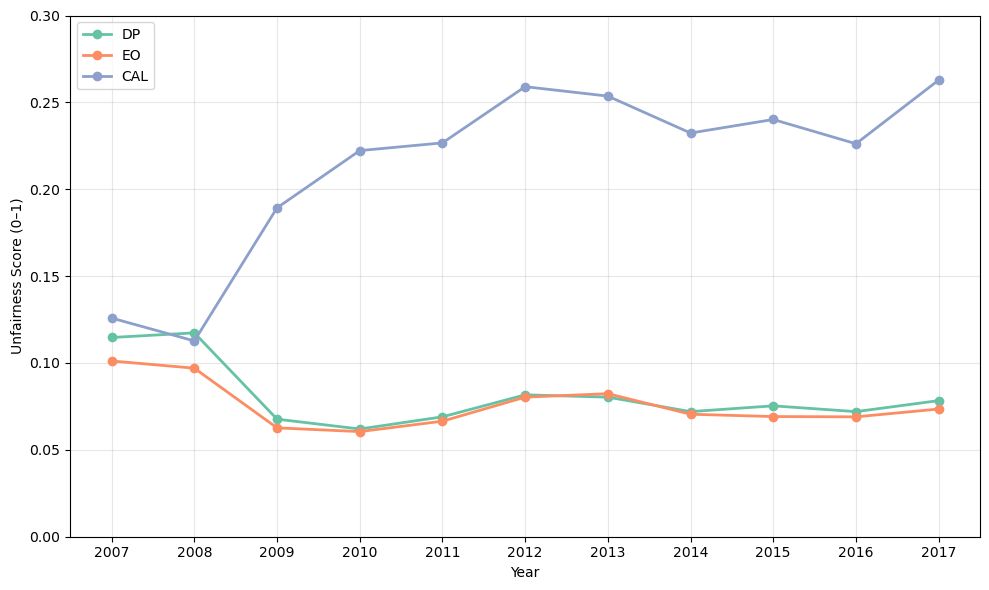

In [8]:
# Set pastel colour scheme
sns.set_palette("Set2")

# Get years
years = sorted(dp_by_year.keys())

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fairness metrics
ax.plot(
    years,
    [dp_by_year[y] for y in years],
    marker="o",
    linewidth=2,
    label="DP"
)

ax.plot(
    years,
    [eo_by_year[y] for y in years],
    marker="o",
    linewidth=2,
    label="EO"
)

ax.plot(
    years,
    [cal_by_year[y] for y in years],
    marker="o",
    linewidth=2,
    label="CAL"
)

# Axis labels
ax.set_xlabel("Year")
ax.set_ylabel("Unfairness Score (0–1)")

# Display y-axis from 0 to 0.4
ax.set_ylim(0, 0.3)

# Show each year on x-axis
ax.set_xticks(years)

# Legend
ax.legend()

# Subtle grid
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Confidence interval calculations

In [9]:
# DP

dp_point, dp_lower, dp_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    pt, lo, hi = dem_parity_total_with_ci(df_year)
    dp_point[year] = pt
    dp_lower[year] = lo
    dp_upper[year] = hi

In [10]:
# EO

eo_point, eo_lower, eo_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    pt, lo, hi = eq_odds_total_with_ci(df_year)
    eo_point[year] = pt
    eo_lower[year] = lo
    eo_upper[year] = hi

In [12]:
# CAL

bin_edges = get_bin_edges(hmda)

cal_point, cal_lower, cal_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda["year"] == year]
    pt, lo, hi = calibration_total_with_ci(df_year, bin_edges)
    cal_point[year] = pt
    cal_lower[year] = lo
    cal_upper[year] = hi

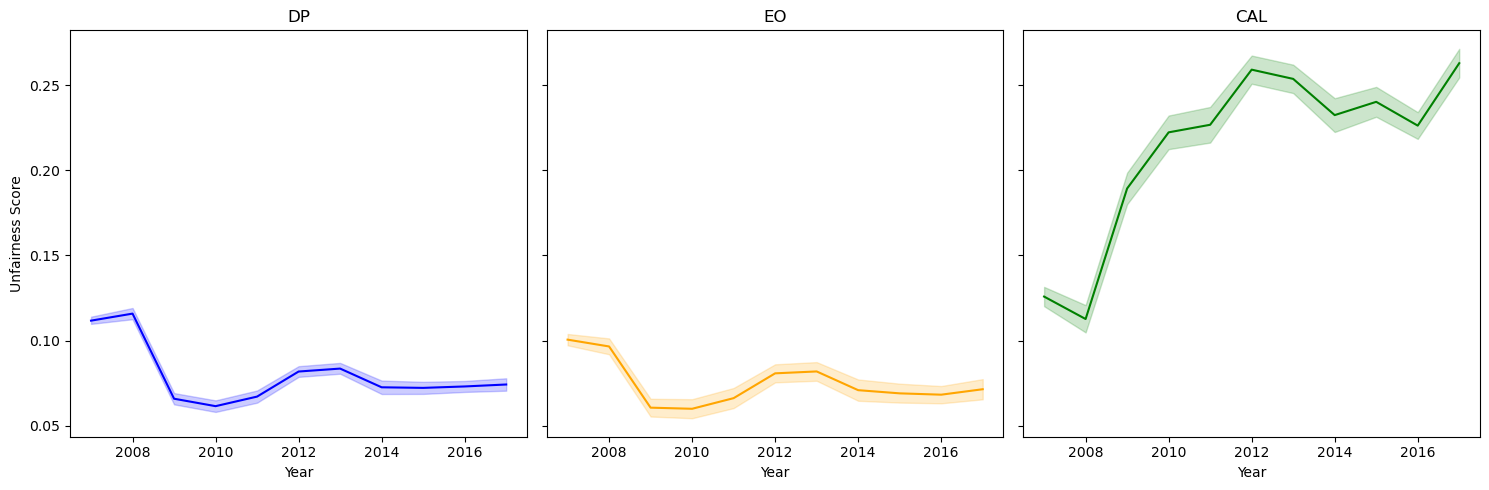

In [13]:
# Plot all three metrics

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

metrics = [
    ("DP", dp_point, dp_lower, dp_upper, "blue"),
    ("EO", eo_point, eo_lower, eo_upper, "orange"),
    ("CAL", cal_point, cal_lower, cal_upper, "green"),
]

for ax, (label, point, lower, upper, colour) in zip(axes, metrics):
    years = sorted(point.keys())
    pts = [point[y] for y in years]
    lows = [lower[y] for y in years]
    highs = [upper[y] for y in years]
    
    ax.plot(years, pts, label=label, color=colour)
    ax.fill_between(years, lows, highs, alpha=0.2, color=colour)
    ax.set_title(label)
    ax.set_xlabel("Year")

axes[0].set_ylabel("Unfairness Score")
plt.tight_layout()
plt.show()

### For reference - DP, EO, and CAL by year

In [ ]:
yearly_figures = [dp_by_year, eo_by_year, cal_by_year]
df_fairness = pd.DataFrame({
    'DP': dp_by_year,
    'EO': eo_by_year,
    'CAL': cal_by_year,
})

df_fairness.to_csv("fairness_numbers.csv")